In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt

import joblib

In [2]:
df = pd.read_csv(
    r"D:\Guvi\Projects\ride_flow_ai\data\preprocessed\cleaned_rides.csv"
)

print(df.head())

   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         2  2024-01-01 00:57:55   2024-01-01 01:17:43              1.0   
1         1  2024-01-01 00:03:00   2024-01-01 00:09:36              1.0   
2         1  2024-01-01 00:17:06   2024-01-01 00:35:01              1.0   
3         1  2024-01-01 00:36:38   2024-01-01 00:44:56              1.0   
4         1  2024-01-01 00:46:51   2024-01-01 00:52:57              1.0   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0           1.72         1.0                  N           186            79   
1           1.80         1.0                  N           140           236   
2           4.70         1.0                  N           236            79   
3           1.40         1.0                  N            79           211   
4           0.80         1.0                  N           211           148   

   payment_type  ...  improvement_surcharge  total_amount  \
0            

In [3]:
np.random.seed(42)

df['ETA'] = np.random.randint(
    2,
    30,
    size=len(df)
)

In [4]:
df['traffic_level'] = np.random.randint(
    1,
    10,
    size=len(df)
)

In [5]:
df['driver_rating'] = np.round(
    np.random.uniform(
        3.0,
        5.0,
        size=len(df)
    ),
    1
)

In [6]:
df['surge_multiplier'] = np.round(
    np.random.uniform(
        1.0,
        3.0,
        size=len(df)
    ),
    2
)

In [16]:
random_noise = np.random.rand(len(df))

df['cancelled'] = np.where(

    (
        (df['ETA'] > 20)
        |
        (df['surge_multiplier'] > 2.2)
        |
        (
            (df['traffic_level'] > 7)
            &
            (df['driver_rating'] < 4)
        )
        |
        (random_noise > 0.97)
    ),

    1,

    0
)

In [17]:
print(
    df['cancelled']
    .value_counts()
)

cancelled
1    64740
0    35230
Name: count, dtype: int64


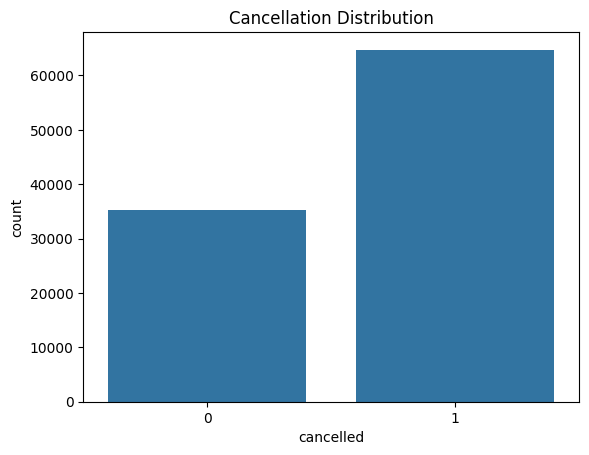

In [18]:
sns.countplot(
    x=df['cancelled']
)

plt.title(
    "Cancellation Distribution"
)

plt.show()

In [19]:
features = [

    'ETA',
    'traffic_level',
    'driver_rating',
    'surge_multiplier',
    'trip_distance',
    'fare_amount'

]

X = df[features]

y = df['cancelled']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

In [21]:
cancel_model = RandomForestClassifier(

    n_estimators=100,

    random_state=42
)

cancel_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [22]:
predictions = cancel_model.predict(X_test)

probabilities = cancel_model.predict_proba(X_test)[:,1]

In [23]:
accuracy = accuracy_score(
    y_test,
    predictions
)

f1 = f1_score(
    y_test,
    predictions
)

roc_auc = roc_auc_score(
    y_test,
    probabilities
)

print("Accuracy :", accuracy)

print("F1 Score :", f1)

print("ROC-AUC :", roc_auc)

Accuracy : 0.9886966089826948
F1 Score : 0.991128209154432
ROC-AUC : 0.9915685116840449


In [24]:
print(

    classification_report(
        y_test,
        predictions
    )

)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      7144
           1       1.00      0.98      0.99     12850

    accuracy                           0.99     19994
   macro avg       0.98      0.99      0.99     19994
weighted avg       0.99      0.99      0.99     19994



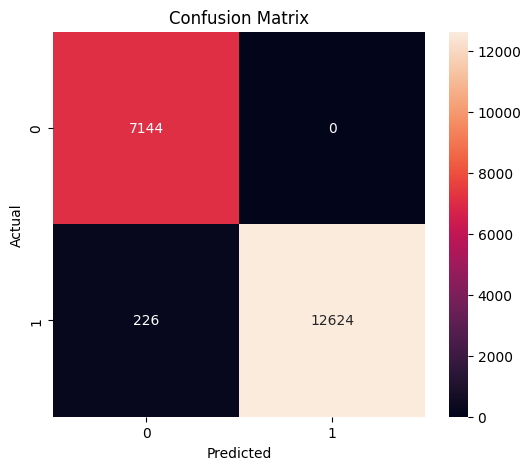

In [25]:
cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [26]:
importance = pd.DataFrame({

    'Feature': features,

    'Importance':
    cancel_model.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

            Feature  Importance
3  surge_multiplier    0.463225
0               ETA    0.375409
1     traffic_level    0.088351
2     driver_rating    0.051292
4     trip_distance    0.013354
5       fare_amount    0.008368


In [27]:
joblib.dump(

    cancel_model,

    r"D:\Guvi\Projects\ride_flow_ai\models\cancellation_prediction_model.pkl"

)

print("Cancellation Model Saved")

Cancellation Model Saved
